# Assignment 3: Probabilistic ML & Time Series I


## Problem 3.1: Bayesian Linear Regression


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, sigma]


C:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 209 seconds.


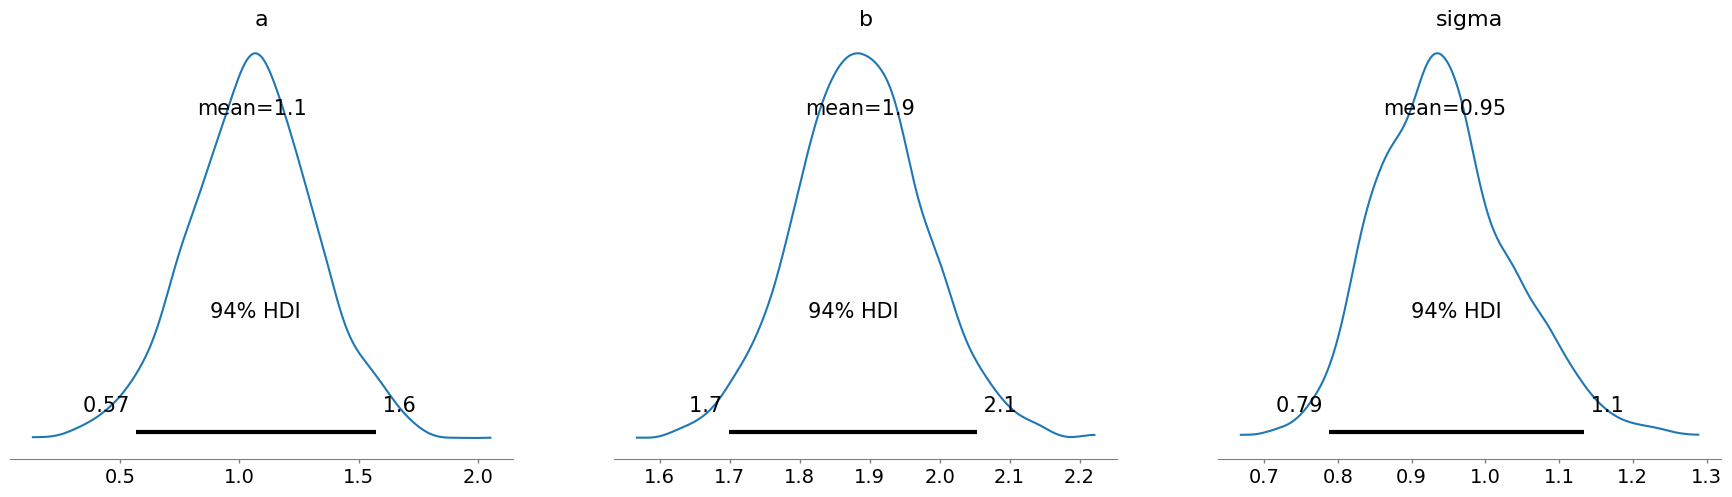

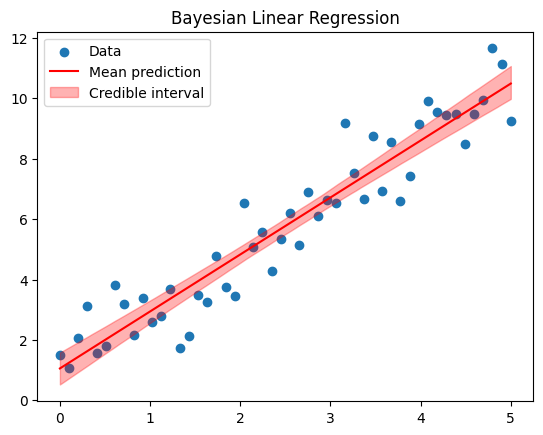

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

# Generate synthetic data
np.random.seed(42)
X = np.linspace(0, 5, 50)
y = 1 + 2*X + np.random.normal(0, 1, size=50)

# Bayesian model
with pm.Model() as model:
    a = pm.Normal("a", mu=0, sigma=10)
    b = pm.Normal("b", mu=0, sigma=10)
    sigma = pm.HalfNormal("sigma", sigma=1)

    mu = a + b * X

    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

    trace = pm.sample(500, tune=500, return_inferencedata=True)

# 🔹 Posterior plots
az.plot_posterior(trace)
plt.show()

# 🔹 Extract samples
a_samples = trace.posterior["a"].values.flatten()
b_samples = trace.posterior["b"].values.flatten()

# 🔹 Predictions
X_new = np.linspace(0, 5, 100)
y_preds = np.array([a + b * X_new for a, b in zip(a_samples, b_samples)])

y_mean = y_preds.mean(axis=0)
y_lower = np.percentile(y_preds, 2.5, axis=0)
y_upper = np.percentile(y_preds, 97.5, axis=0)

# 🔹 Final visualization
plt.figure()
plt.scatter(X, y, label="Data")
plt.plot(X_new, y_mean, color="red", label="Mean prediction")
plt.fill_between(X_new, y_lower, y_upper, color="red", alpha=0.3, label="Credible interval")

plt.legend()
plt.title("Bayesian Linear Regression")
plt.show()

### Bayesian Linear Regression Analysis



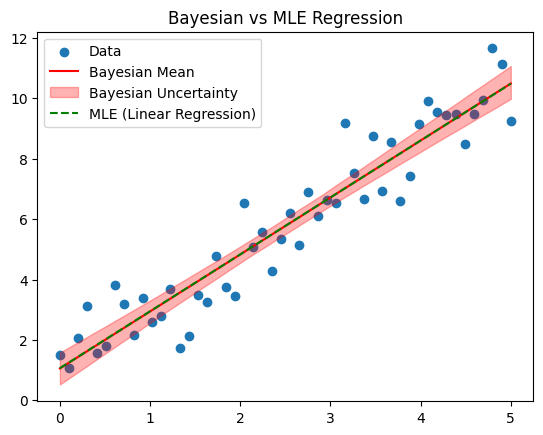

In [9]:
from sklearn.linear_model import LinearRegression

# Fit MLE model
X_reshaped = X.reshape(-1, 1)
mle_model = LinearRegression()
mle_model.fit(X_reshaped, y)

# MLE predictions
y_mle = mle_model.predict(X_new.reshape(-1,1))

# Plot comparison
plt.figure()
plt.scatter(X, y, label="Data")

# Bayesian
plt.plot(X_new, y_mean, color="red", label="Bayesian Mean")
plt.fill_between(X_new, y_lower, y_upper, color="red", alpha=0.3, label="Bayesian Uncertainty")

# MLE
plt.plot(X_new, y_mle, color="green", linestyle="--", label="MLE (Linear Regression)")

plt.legend()
plt.title("Bayesian vs MLE Regression")
plt.show()

### Comparison with Maximum Likelihood Estimation



## Problem 3.2: Gaussian Process Regression

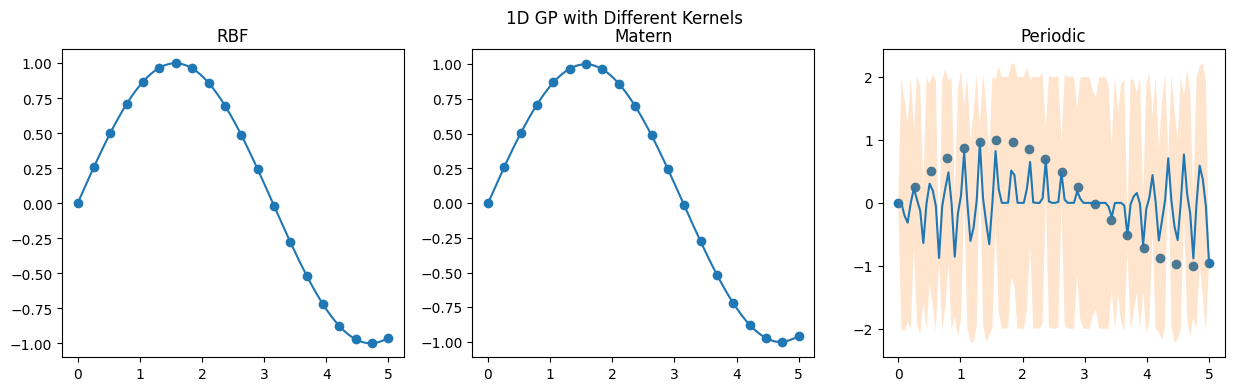

C:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\gaussian_process\_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 6 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


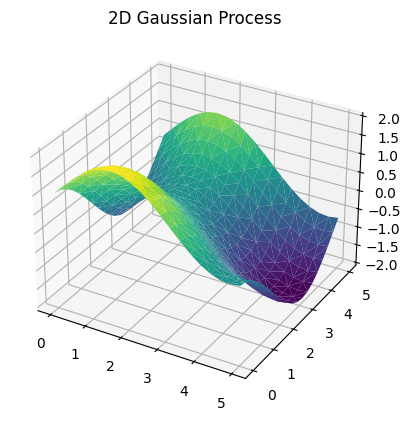

C:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianProcessRegressor was fitted with feature names
  warnings.warn(


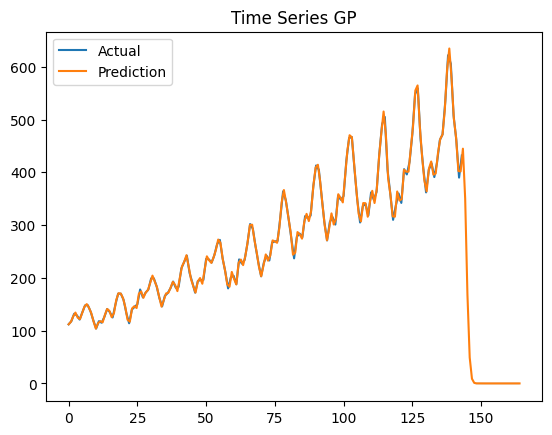

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ExpSineSquared
from mpl_toolkits.mplot3d import Axes3D

# =========================
# 1D DATA
# =========================
np.random.seed(42)
X = np.atleast_2d(np.linspace(0, 5, 20)).T
y = np.sin(X).ravel()

X_test = np.linspace(0, 5, 100).reshape(-1,1)

# =========================
# KERNEL COMPARISON
# =========================
kernels = {
    "RBF": RBF(),
    "Matern": Matern(),
    "Periodic": ExpSineSquared()
}

plt.figure(figsize=(15,4))

for i, (name, kernel) in enumerate(kernels.items()):
    gp = GaussianProcessRegressor(kernel=kernel)
    gp.fit(X, y)
    y_pred, std = gp.predict(X_test, return_std=True)

    plt.subplot(1,3,i+1)
    plt.scatter(X, y)
    plt.plot(X_test, y_pred)
    plt.fill_between(X_test.ravel(), y_pred-2*std, y_pred+2*std, alpha=0.2)
    plt.title(name)

plt.suptitle("1D GP with Different Kernels")
plt.show()

# =========================
# 2D DATA
# =========================
x1 = np.linspace(0, 5, 20)
x2 = np.linspace(0, 5, 20)
X1, X2 = np.meshgrid(x1, x2)

X_2d = np.column_stack([X1.ravel(), X2.ravel()])
y_2d = np.sin(X1).ravel() + np.cos(X2).ravel()

gp_2d = GaussianProcessRegressor(kernel=RBF())
gp_2d.fit(X_2d, y_2d)

y_pred_2d = gp_2d.predict(X_2d)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(X_2d[:,0], X_2d[:,1], y_pred_2d, cmap='viridis')
plt.title("2D Gaussian Process")
plt.show()

# =========================
# TIME SERIES (AIRLINE DATA)
# =========================
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
data = pd.read_csv(url)

data['t'] = np.arange(len(data))

X_ts = data[['t']]
y_ts = data['Passengers']

gp_ts = GaussianProcessRegressor(kernel=RBF())
gp_ts.fit(X_ts, y_ts)

X_future = np.linspace(0, len(data)+20, 200).reshape(-1,1)
y_pred_ts, std_ts = gp_ts.predict(X_future, return_std=True)

plt.figure()
plt.plot(X_ts, y_ts, label="Actual")
plt.plot(X_future, y_pred_ts, label="Prediction")
plt.fill_between(X_future.ravel(), y_pred_ts-2*std_ts, y_pred_ts+2*std_ts, alpha=0.2)
plt.title("Time Series GP")
plt.legend()
plt.show()

### Gaussian Process Regression Analysis
